# BrushCue Example: RGB Color Shift

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/rgb_color_shift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/rgb-color-shift

In [ ]:
!pip install brushcue

new pipeline: painter_Tessellated_fill_solid_no_brush_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_15869156322426445765_inarr_false
new pipeline: blend_Add_rgba16float_compute_bg_false_fg_false
new pipeline: color_transformer_shader_rgba16float_compute_16861657794771480865_inarr_false


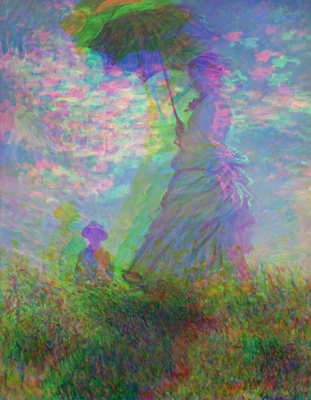

In [1]:
import io
from PIL import Image

import brushcue as bc

variable_0 = bc.Composition.monet_women_with_parasol()
variable_1 = bc.Vector2i.from_components(84, 30).passthrough()
variable_2 = bc.Vector2i.from_components(-56, -69).passthrough()
variable_3 = variable_1.x().abs().max(variable_2.x().abs()).passthrough()
variable_4 = variable_1.y().abs().max(variable_2.y().abs()).passthrough()
variable_5 = variable_0.bounds()
variable_6 = variable_0.bounds()
graph = (
    variable_0.linear_transform(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1)
    .blend_add(
        variable_0.linear_transform(
            0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1
        ).blend_add(
            variable_0.linear_transform(1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1),
            bc.Transform2.identity().translation(
                bc.Vector2f.from_components(
                    variable_1.x().to_float(), variable_1.y().to_float()
                )
            ),
        ),
        bc.Transform2.identity().translation(
            bc.Vector2f.from_components(
                variable_2.x().to_float(), variable_2.y().to_float()
            )
        ),
    )
    .crop(
        bc.Bounds2f.from_x_y_width_height(
            variable_3.to_float(),
            variable_4.to_float(),
            (
                bc.Vector2i.from_components(
                    variable_5.width().round_to_int(),
                    variable_5.height().round_to_int(),
                ).x()
                - (variable_3 * 2)
            ).to_float(),
            (
                bc.Vector2i.from_components(
                    variable_6.width().round_to_int(),
                    variable_6.height().round_to_int(),
                ).y()
                - (variable_4 * 2)
            ).to_float(),
        )
    )
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
